# TP - Clasificación Multiclase de Texto con Regresión Softmax
### Redes Neuronales / Deep Learning

Dataset: **20 Newsgroups** (~18.000 posts de foros de Usenet, clasificados en 20 categorías).

## Objetivos
- Implementar un pipeline de preprocesamiento de texto **configurable** (stopwords, stemming, lematización, n-gramas).
- Implementar una **Regresión Softmax** (regresión logística multinomial) en PyTorch: una única capa lineal + `CrossEntropyLoss`, sin capas ocultas.
- Trackear el entrenamiento con **TensorBoard** y **MLflow**.
- Usar **Optuna** para buscar la mejor combinación de hiperparámetros de preprocesamiento *y* de entrenamiento en conjunto.

## Qué hay que completar
Los bloques marcados `# TODO` son los que tienen que completar ustedes. El resto ya está resuelto.

Esta notebook es individual/standalone: no tiene una sección de defensa grupal asociada.


## 0. Setup

In [ ]:
!pip install -q mlflow optuna


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14

In [ ]:
import re
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

from torch.utils.tensorboard import SummaryWriter
import mlflow
import mlflow.pytorch
import optuna

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)


Usando dispositivo: cpu


In [ ]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("punkt")
nltk.download("punkt_tab")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## 1. Datos: 20 Newsgroups

Usamos `remove=('headers', 'footers', 'quotes')` para sacar metadata que haría el problema "demasiado fácil" (por ejemplo, el header a veces incluye el nombre del newsgroup).

In [ ]:
newsgroups_train = fetch_20newsgroups(subset="train", remove=("headers", "footers", "quotes"))
newsgroups_test  = fetch_20newsgroups(subset="test",  remove=("headers", "footers", "quotes"))

class_names = newsgroups_train.target_names
NUM_CLASSES = len(class_names)
print(f"Clases ({NUM_CLASSES}):", class_names)
print(f"\nTrain: {len(newsgroups_train.data)} documentos | Test: {len(newsgroups_test.data)} documentos")

print("\n--- Ejemplo de documento ---")
print("Categoría:", class_names[newsgroups_train.target[0]])
print(newsgroups_train.data[0][:500])


Clases (20): ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']

Train: 11314 documentos | Test: 7532 documentos

--- Ejemplo de documento ---
Categoría: rec.autos
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


## 2. Preprocesamiento configurable

Vamos a armar una función de preprocesamiento con estos hiperparámetros (todos van a formar parte de la búsqueda de Optuna más adelante):

- `remove_stopwords` (`True`/`False`): sacar palabras muy frecuentes y poco informativas (`the`, `is`, `and`, ...).
- `normalization` (`"none"` / `"stem"` / `"lemmatize"`):
  - `"none"`: no se normaliza la palabra.
  - `"stem"`: **stemming** con Porter Stemmer — corta la palabra a una raíz heurística (`"running"` → `"run"`, a veces resultados no son palabras reales: `"studies"` → `"studi"`).
  - `"lemmatize"`: **lematización** con WordNet — lleva la palabra a su forma de diccionario (`"running"` → `"run"`, `"studies"` → `"study"`), más lenta pero más "correcta" lingüísticamente.

### TODO 1: completar `preprocess_text`

Pasos esperados:
1. Tokenizar el texto con `word_tokenize`.
2. Pasar todo a minúsculas y quedarse solo con tokens alfabéticos (`token.isalpha()`), para descartar números y puntuación.
3. Si `remove_stopwords` es `True`, sacar los tokens que estén en el set de stopwords.
4. Según `normalization`, aplicar `stemmer.stem(token)`, `lemmatizer.lemmatize(token)`, o dejar el token igual.
5. Devolver los tokens unidos con espacios (un string, para poder pasárselo después a `TfidfVectorizer`).

In [ ]:
STOP_WORDS = set(stopwords.words("english"))
STEMMER = PorterStemmer()
LEMMATIZER = WordNetLemmatizer()


def preprocess_text(text, remove_stopwords, normalization):
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha()]

    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP_WORDS]

    if normalization == "stem":
        tokens = [STEMMER.stem(t) for t in tokens]
    elif normalization == "lemmatize":
        tokens = [LEMMATIZER.lemmatize(t) for t in tokens]

    return " ".join(tokens)


In [ ]:
# Sanity check: probamos las distintas combinaciones sobre una oración de ejemplo
ejemplo = "The researchers were studying the running processes and stopping conditions of the engines."
for norm in ["none", "stem", "lemmatize"]:
    for rm_sw in [False, True]:
        resultado = preprocess_text(ejemplo, remove_stopwords=rm_sw, normalization=norm)
        print(f"normalization={norm:10s} remove_stopwords={str(rm_sw):5s} -> {resultado}")


normalization=none       remove_stopwords=False -> the researchers were studying the running processes and stopping conditions of the engines
normalization=none       remove_stopwords=True  -> researchers studying running processes stopping conditions engines
normalization=stem       remove_stopwords=False -> the research were studi the run process and stop condit of the engin
normalization=stem       remove_stopwords=True  -> research studi run process stop condit engin
normalization=lemmatize  remove_stopwords=False -> the researcher were studying the running process and stopping condition of the engine
normalization=lemmatize  remove_stopwords=True  -> researcher studying running process stopping condition engine


## 3. Vectorización TF-IDF

Convertimos los textos preprocesados en vectores numéricos con `TfidfVectorizer`. Como el preprocesamiento (tokenización, stopwords, normalización) ya lo hicimos nosotros, acá solo controlamos:

- `ngram_range`: `(1,1)` solo unigramas, o `(1,2)` unigramas + bigramas (captura algo de contexto, ej. `"new york"`).
- `max_features`: tamaño máximo del vocabulario (se queda con los términos más frecuentes).
- `min_df`: un término tiene que aparecer en al menos `min_df` documentos para entrar al vocabulario (filtra términos rarísimos / errores de tipeo).

### TODO 2: completar `vectorize_data`

In [ ]:
def vectorize_data(train_texts, test_texts, ngram_range, max_features, min_df):
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=max_features,
        min_df=min_df
    )
    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)
    return X_train, X_test, vectorizer


In [ ]:
# Sanity check rápido con pocos documentos
_sample_train = ["the cat sat on the mat", "dogs are running in the park", "cats and dogs are pets"]
_sample_test = ["the dog sat on the mat"]
_Xtr, _Xte, _vec = vectorize_data(_sample_train, _sample_test, ngram_range=(1, 1), max_features=50, min_df=1)
assert _Xtr is not None, "Completá vectorize_data"
print("Shape train:", _Xtr.shape, "| Shape test:", _Xte.shape)
print("Vocabulario (parcial):", list(_vec.vocabulary_.keys())[:10])


Shape train: (3, 13) | Shape test: (1, 13)
Vocabulario (parcial): ['the', 'cat', 'sat', 'on', 'mat', 'dogs', 'are', 'running', 'in', 'park']


## 4. Modelo: Regresión Softmax

La regresión softmax (regresión logística multinomial) es el modelo más simple posible para clasificación multiclase: **una sola capa lineal** que mapea el vector de entrada a un score (logit) por clase, sin ninguna no-linealidad ni capa oculta.

`CrossEntropyLoss` de PyTorch ya incluye internamente un `log_softmax` + `NLLLoss`, así que el modelo **no debe aplicar softmax en el forward** — hay que devolver los logits crudos.

### TODO 3: completar `SoftmaxRegression`

In [ ]:
class SoftmaxRegression(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.linear(x)


In [ ]:
# Sanity check
_dummy = torch.randn(4, 50)
_model_check = SoftmaxRegression(input_dim=50, num_classes=20)
_out = _model_check(_dummy)
assert _out is not None and _out.shape == (4, 20), "Revisá SoftmaxRegression"
print("Shape de salida OK:", _out.shape)


Shape de salida OK: torch.Size([4, 20])


## 5. Entrenamiento (ya resuelto)

Dado que los datos vectorizados entran en memoria sin problema, armamos `DataLoader`s a partir de tensores densos. Logueamos loss y accuracy (train y validación) por época a TensorBoard, y a MLflow además los hiperparámetros y el modelo final.

In [ ]:
%load_ext tensorboard


In [ ]:
def to_tensor_dataset(X, y):
    X_dense = torch.tensor(X.toarray(), dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)
    return TensorDataset(X_dense, y_tensor)


def train_softmax_model(model, train_loader, val_loader, optimizer, epochs, writer=None, run_name="softmax"):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += xb.size(0)
        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                running_loss += loss.item() * xb.size(0)
                correct += (logits.argmax(dim=1) == yb).sum().item()
                total += xb.size(0)
        val_loss, val_acc = running_loss / total, correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"[{run_name}] Epoch {epoch+1}/{epochs} - "
              f"train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} - "
              f"val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")

        if writer is not None:
            writer.add_scalars("loss", {"train": train_loss, "val": val_loss}, epoch)
            writer.add_scalars("accuracy", {"train": train_acc, "val": val_acc}, epoch)
        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("val_loss", val_loss, step=epoch)
        mlflow.log_metric("train_acc", train_acc, step=epoch)
        mlflow.log_metric("val_acc", val_acc, step=epoch)

    return history


## 6. Búsqueda de hiperparámetros con Optuna

La búsqueda incluye **hiperparámetros de preprocesamiento** (`remove_stopwords`, `normalization`, `ngram_range`, `max_features`, `min_df`) y **de entrenamiento** (`lr`, `batch_size`), todos en un mismo `objective`.

**Optimización de tiempo**: como la tokenización + stopwords + normalización es lo más lento del pipeline (y solo depende de `remove_stopwords` y `normalization`, que tienen pocas combinaciones posibles), la precalculamos una sola vez para las 6 combinaciones posibles y la cacheamos. Así, cada trial de Optuna solo repite la parte rápida (vectorizar + entrenar pocas épocas).

In [ ]:
print("Precalculando preprocesamiento para las 6 combinaciones posibles (puede tardar unos minutos)...")
preprocessed_cache = {}
for remove_stopwords in [False, True]:
    for normalization in ["none", "stem", "lemmatize"]:
        key = (remove_stopwords, normalization)
        train_proc = [preprocess_text(t, remove_stopwords, normalization) for t in newsgroups_train.data]
        test_proc  = [preprocess_text(t, remove_stopwords, normalization) for t in newsgroups_test.data]
        preprocessed_cache[key] = (train_proc, test_proc)
        print("  listo:", key)


Precalculando preprocesamiento para las 6 combinaciones posibles (puede tardar unos minutos)...
  listo: (False, 'none')
  listo: (False, 'stem')
  listo: (False, 'lemmatize')
  listo: (True, 'none')
  listo: (True, 'stem')
  listo: (True, 'lemmatize')


In [ ]:
def objective(trial):
    remove_stopwords = trial.suggest_categorical("remove_stopwords", [False, True])
    normalization = trial.suggest_categorical("normalization", ["none", "stem", "lemmatize"])
    ngram_range = trial.suggest_categorical("ngram_range", ["1gram", "1_2gram"])
    ngram_range_tuple = (1, 1) if ngram_range == "1gram" else (1, 2)
    max_features = trial.suggest_categorical("max_features", [2000, 5000, 10000])
    min_df = trial.suggest_categorical("min_df", [1, 2, 5])
    lr = trial.suggest_float("lr", 1e-3, 1e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    train_texts, test_texts = preprocessed_cache[(remove_stopwords, normalization)]
    # Partimos una porción de train como validación para la búsqueda (no usamos el test acá)
    tr_texts, val_texts, tr_labels, val_labels = train_test_split(
        train_texts, newsgroups_train.target, test_size=0.2, random_state=SEED,
        stratify=newsgroups_train.target,
    )

    X_tr, X_val, _ = vectorize_data(tr_texts, val_texts, ngram_range_tuple, max_features, min_df)
    train_loader = DataLoader(to_tensor_dataset(X_tr, tr_labels), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(to_tensor_dataset(X_val, val_labels), batch_size=batch_size, shuffle=False)

    model = SoftmaxRegression(input_dim=X_tr.shape[1], num_classes=NUM_CLASSES)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = train_softmax_model(model, train_loader, val_loader, optimizer, epochs=5, run_name=f"trial_{trial.number}")

    return history["val_acc"][-1]


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("Mejores hiperparámetros:", study.best_params)
print("Mejor accuracy de validación:", study.best_value)


[I 2026-09-24 22:27:32,034] A new study created in memory with name: no-name-edb888ec-aad3-425a-a254-869025059f25


[trial_0] Epoch 1/5 - train_loss: 2.0872 train_acc: 0.5877 - val_loss: 1.5029 val_acc: 0.6947


2026/09/24 22:27:47 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/24 22:27:47 INFO mlflow.store.db.utils: Updating database tables


[trial_0] Epoch 2/5 - train_loss: 0.9605 train_acc: 0.8692 - val_loss: 1.1912 val_acc: 0.7167
[trial_0] Epoch 3/5 - train_loss: 0.6131 train_acc: 0.9177 - val_loss: 1.0806 val_acc: 0.7181
[trial_0] Epoch 4/5 - train_loss: 0.4421 train_acc: 0.9419 - val_loss: 1.0271 val_acc: 0.7221


[I 2026-09-24 22:27:54,331] Trial 0 finished with value: 0.7176314626601856 and parameters: {'remove_stopwords': False, 'normalization': 'lemmatize', 'ngram_range': '1gram', 'max_features': 10000, 'min_df': 2, 'lr': 0.01290422567916105, 'batch_size': 32}. Best is trial 0 with value: 0.7176314626601856.


...

[trial_12] Epoch 5/5 - train_loss: 0.8797 train_acc: 0.8937 - val_loss: 1.2594 val_acc: 0.7061
[trial_13] Epoch 1/5 - train_loss: 2.6983 train_acc: 0.4908 - val_loss: 2.4137 val_acc: 0.6597
[trial_13] Epoch 2/5 - train_loss: 2.0710 train_acc: 0.8072 - val_loss: 2.0150 val_acc: 0.6924
[trial_13] Epoch 3/5 - train_loss: 1.6359 train_acc: 0.8548 - val_loss: 1.7478 val_acc: 0.7070
[trial_13] Epoch 4/5 - train_loss: 1.3303 train_acc: 0.8828 - val_loss: 1.5631 val_acc: 0.7137


[I 2026-09-24 22:29:49,682] Trial 13 finished with value: 0.7149801148917366 and parameters: {'remove_stopwords': False, 'normalization': 'lemmatize', 'ngram_range': '1gram', 'max_features': 10000, 'min_df': 1, 'lr': 0.003055985630066581, 'batch_size': 32}. Best is trial 0 with value: 0.7176314626601856.


[trial_13] Epoch 5/5 - train_loss: 1.1117 train_acc: 0.8943 - val_loss: 1.4335 val_acc: 0.7150
[trial_14] Epoch 1/5 - train_loss: 2.6826 train_acc: 0.5184 - val_loss: 2.3881 val_acc: 0.6483
[trial_14] Epoch 2/5 - train_loss: 2.0336 train_acc: 0.8007 - val_loss: 1.9819 val_acc: 0.6916
[trial_14] Epoch 3/5 - train_loss: 1.5919 train_acc: 0.8567 - val_loss: 1.7133 val_acc: 0.7092
[trial_14] Epoch 4/5 - train_loss: 1.2869 train_acc: 0.8812 - val_loss: 1.5332 val_acc: 0.7159


[I 2026-09-24 22:29:57,511] Trial 14 finished with value: 0.7189571365444101 and parameters: {'remove_stopwords': False, 'normalization': 'lemmatize', 'ngram_range': '1gram', 'max_features': 10000, 'min_df': 1, 'lr': 0.003215630164774041, 'batch_size': 32}. Best is trial 14 with value: 0.7189571365444101.


[trial_14] Epoch 5/5 - train_loss: 1.0712 train_acc: 0.8989 - val_loss: 1.4065 val_acc: 0.7190
Mejores hiperparámetros: {'remove_stopwords': False, 'normalization': 'lemmatize', 'ngram_range': '1gram', 'max_features': 10000, 'min_df': 1, 'lr': 0.003215630164774041, 'batch_size': 32}
Mejor accuracy de validación: 0.7189571365444101


## 7. Entrenamiento final

Usamos los mejores hiperparámetros encontrados por Optuna, entrenamos con **todo** el train set y por más épocas, evaluando contra el test set real (que no se usó en la búsqueda).

In [ ]:
mlflow.end_run()
best = study.best_params
BEST_REMOVE_SW = best["remove_stopwords"]
BEST_NORM = best["normalization"]
BEST_NGRAM = (1, 1) if best["ngram_range"] == "1gram" else (1, 2)
BEST_MAX_FEATURES = best["max_features"]
BEST_MIN_DF = best["min_df"]
BEST_LR = best["lr"]
BEST_BATCH_SIZE = best["batch_size"]
EPOCHS_FINAL = 20

train_texts_final, test_texts_final = preprocessed_cache[(BEST_REMOVE_SW, BEST_NORM)]
X_train_final, X_test_final, vectorizer_final = vectorize_data(
    train_texts_final, test_texts_final, BEST_NGRAM, BEST_MAX_FEATURES, BEST_MIN_DF
)

train_loader_final = DataLoader(to_tensor_dataset(X_train_final, newsgroups_train.target),
                                 batch_size=BEST_BATCH_SIZE, shuffle=True)
test_loader_final = DataLoader(to_tensor_dataset(X_test_final, newsgroups_test.target),
                                batch_size=BEST_BATCH_SIZE, shuffle=False)

model = SoftmaxRegression(input_dim=X_train_final.shape[1], num_classes=NUM_CLASSES)
optimizer = optim.Adam(model.parameters(), lr=BEST_LR)
writer = SummaryWriter(log_dir="runs/softmax_final")

mlflow.set_experiment("softmax_20newsgroups")
with mlflow.start_run(run_name="softmax_final"):
    mlflow.log_params({
        "remove_stopwords": BEST_REMOVE_SW, "normalization": BEST_NORM,
        "ngram_range": str(BEST_NGRAM), "max_features": BEST_MAX_FEATURES, "min_df": BEST_MIN_DF,
        "lr": BEST_LR, "batch_size": BEST_BATCH_SIZE, "epochs": EPOCHS_FINAL,
    })
    history = train_softmax_model(model, train_loader_final, test_loader_final, optimizer,
                                   epochs=EPOCHS_FINAL, writer=writer, run_name="final")

    # Get an input example from the training data loader
    sample_input, _ = next(iter(train_loader_final))
    mlflow.pytorch.log_model(model, "model", input_example=sample_input.to(device), serialization_format="pickle")

writer.close()

[final] Epoch 1/20 - train_loss: 2.6148 train_acc: 0.5421 - val_loss: 2.3397 val_acc: 0.6171
[final] Epoch 2/20 - train_loss: 1.8964 train_acc: 0.8040 - val_loss: 1.9457 val_acc: 0.6541
[final] Epoch 3/20 - train_loss: 1.4511 train_acc: 0.8485 - val_loss: 1.7077 val_acc: 0.6616
[final] Epoch 4/20 - train_loss: 1.1629 train_acc: 0.8739 - val_loss: 1.5565 val_acc: 0.6645
[final] Epoch 5/20 - train_loss: 0.9659 train_acc: 0.8917 - val_loss: 1.4543 val_acc: 0.6661
[final] Epoch 6/20 - train_loss: 0.8230 train_acc: 0.9053 - val_loss: 1.3826 val_acc: 0.6691
[final] Epoch 7/20 - train_loss: 0.7149 train_acc: 0.9149 - val_loss: 1.3304 val_acc: 0.6690
[final] Epoch 8/20 - train_loss: 0.6299 train_acc: 0.9261 - val_loss: 1.2914 val_acc: 0.6682
[final] Epoch 9/20 - train_loss: 0.5610 train_acc: 0.9318 - val_loss: 1.2604 val_acc: 0.6689
[final] Epoch 10/20 - train_loss: 0.5041 train_acc: 0.9375 - val_loss: 1.2376 val_acc: 0.6686
[final] Epoch 11/20 - train_loss: 0.4564 train_acc: 0.9426 - val_loss

2026/09/24 22:37:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/24 22:37:19 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


[final] Epoch 20/20 - train_loss: 0.2294 train_acc: 0.9650 - val_loss: 1.1736 val_acc: 0.6613


2026/09/24 22:37:19 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/09/24 22:37:29 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


In [ ]:
%tensorboard --logdir runs


<IPython.core.display.Javascript object>

## 8. Evaluación final

In [ ]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader_final:
        xb = xb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy en test: {test_accuracy:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


Accuracy en test: 0.6613

                          precision    recall  f1-score   support

             alt.atheism       0.47      0.46      0.47       319
           comp.graphics       0.60      0.61      0.61       389
 comp.os.ms-windows.misc       0.59      0.59      0.59       394
comp.sys.ibm.pc.hardware       0.61      0.61      0.61       392
   comp.sys.mac.hardware       0.67      0.63      0.65       385
          comp.windows.x       0.75      0.67      0.71       395
            misc.forsale       0.78      0.78      0.78       390
               rec.autos       0.69      0.68      0.69       396
         rec.motorcycles       0.74      0.69      0.71       398
      rec.sport.baseball       0.54      0.81      0.65       397
        rec.sport.hockey       0.88      0.86      0.87       399
               sci.crypt       0.81      0.68      0.74       396
         sci.electronics       0.59      0.57      0.58       393
                 sci.med       0.77      0.73    

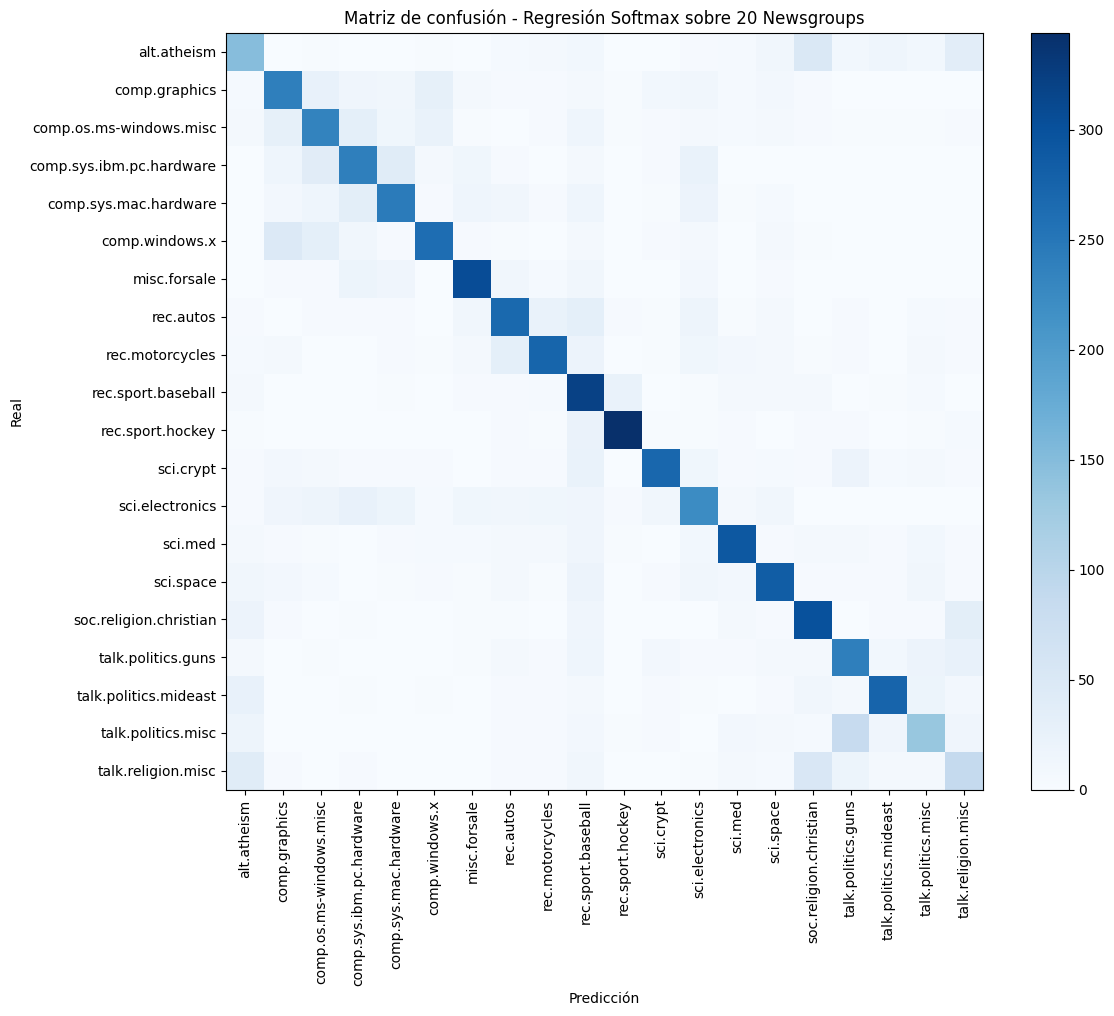

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(NUM_CLASSES), class_names, rotation=90)
plt.yticks(range(NUM_CLASSES), class_names)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Regresión Softmax sobre 20 Newsgroups")
plt.tight_layout()
plt.show()


## 9. Preguntas de reflexión

**Sobre Regresión Softmax (teoría)**
1. ¿Por qué la regresión softmax es una generalización de la regresión logística binaria? ¿Qué pasaría si `NUM_CLASSES = 2`?
2. ¿Por qué `CrossEntropyLoss` en PyTorch no necesita que se le aplique `softmax` antes en el forward? ¿Qué pasaría si igual lo aplicaran (softmax + CrossEntropyLoss)?
3. ¿Qué tipo de frontera de decisión puede aprender un modelo de regresión softmax? ¿Qué limitación tiene frente a un problema que no es linealmente separable?
4. ¿En qué se diferencia este modelo de una red neuronal con capas ocultas? ¿En qué situación elegirían una sobre la otra?

**Sobre frameworks y herramientas**
5. ¿Qué ventajas y desventajas tiene implementar esto en PyTorch (como hicimos) comparado con usar directamente `sklearn.linear_model.LogisticRegression(multi_class="multinomial")`?
6. ¿Para qué sirvió específicamente MLflow en este TP? ¿En qué se diferencia de lo que loguea TensorBoard?
7. ¿Qué ventaja concreta les dio Optuna frente a probar combinaciones de hiperparámetros a mano?

**Sobre el experimento**
8. ¿Qué combinación de preprocesamiento (stopwords, stemming/lematización, n-gramas) encontró Optuna como mejor? ¿Tiene sentido para este dataset?
9. ¿En qué categorías del dataset se confunde más el modelo (según la matriz de confusión)? ¿Por qué creen que pasa (piensen en el contenido temático de esas categorías)?
10. ¿Cambiaría su respuesta a la pregunta anterior si usaran un modelo con capas ocultas en vez de regresión softmax? ¿Por qué sí o por qué no?


**Respuesta a preguntas de reflexión**
1. La regresión softmax es la extensión natural de la logística binaria al caso de más de dos clases. La logística toma una combinación lineal de los atributos y la pasa por una sigmoide para obtener la probabilidad de una sola clase (la otra queda implícita, es "1 menos esa probabilidad"). Softmax hace básicamente lo mismo pero con un score lineal por cada clase, y después los normaliza a todos juntos para que las probabilidades sumen 1. Si ponemos num_classes=2 , el modelo no deja de tener sentido ni cambia de comportamiento: matemáticamente termina siendo equivalente a la regresión logística de siempre, porque la diferencia entre los dos logits reproduce exactamente la misma sigmoide.
2. No hace falta aplicar softmax antes porque CrossEntropyLoss ya lo hace por dentro: combina un log softmax con la pérdida de verosimilitud negativa, y lo hace de una manera numéricamente más segura, evitando que los números exploten o se vayan a cero cuando los logits son grandes. Si igual aplicáramos softmax antes de mandarlo a la loss, estaríamos aplicando softmax dos veces: la salida ya normalizada entre 0 y 1 se vuelve a meter en el cálculo interno de la loss como si fuera un logit crudo.
3. Este modelo solo puede trazar fronteras rectas entre clases, porque toda la transformación que hace es lineal. No hay ninguna no linealidad de por medio. Eso funciona bien si las clases son más o menos separables con una línea recta en el espacio de atributos, pero si el problema requiere una frontera curva o más compleja, el modelo simplemente no puede aprenderla por más que se entrene mejor o más tiempo. Ahí el error queda ligado a un piso que no se puede bajar sin cambiar de arquitectura.
4. La diferencia central con una red con capas ocultas es que esta última mete funciones de activación no lineales entre las capas, lo que le permite combinar los atributos de formas mucho mejor y aprender representaciones intermedias, no solo una frontera lineal directa entre entrada y salida. En la práctica, conviene quedarse con la regresión softmax cuando el problema es simple o linealmente separable, cuando hay pocos datos, o cuando importa poder interpretar fácilmente los pesos del modelo. Conviene pasar a una red con capas ocultas cuando la relación entre los datos y las clases es más compleja y no lineal, y se cuenta con suficientes datos y cómputo para entrenarla sin que se sobreajuste.
5. Usar sklearn.linear_model.LogisticRegression(multi_class="multinomial") es mucho más directo ya que en pocas líneas se tiene un modelo entrenado, con un solver ya optimizado y probado, sin tener en cuenta el bucle de entrenamiento ni detalles numéricos. La contra es que da poco margen de control. No se puede meter fácilmente en un pipeline con mini-batches, GPU, o logging de métricas por época, y tampoco escala naturalmente hacia arquitecturas más complejas. Implementarlo en PyTorch, implica escribir más código y hacerse cargo de cosas que sklearn resuelve solo, pero a cambio da control total sobre el entrenamiento, permite usar GPU, integrar TensorBoard y MLflow.
6. MLflow se usó para llevar un registro ordenado del experimento como qué hiperparámetros se usaron, qué métricas dieron, y guardar el modelo entrenado como un artefacto que se puede recuperar después. Permite comparar distintas corridas entre sí y saber exactamente qué configuración generó qué resultado. TensorBoard cumple un rol distinto, sirve para ver en tiempo real cómo evoluciona el entrenamiento dentro de una corrida puntual, con las curvas de loss y accuracy época a época.
7. La ventaja de Optuna frente a probar combinaciones a mano es que no explora a ciegas sino que usa lo que aprendió de los trials anteriores para decidir qué combinación probar después, en vez de ir tanteando o recorrer todas las combinaciones posibles una por una. Además permite buscar simultáneamente sobre hiperparámetros de tipos distintos, categóricos como la normalización y continuos como el learning rate, en una sola búsqueda coordinada. Esto hace que en pocas corridas se llegue a una combinación razonablemente buena, algo que a mano hubiera llevado mucho más tiempo y probablemente con peor resultado.
8. Optuna terminó eligiendo no sacar las stopwords, aplicar lematización y quedarse solo con unigramas, con una accuracy de validación de casi 72%.
Que gane la lematización por sobre el stemming es logico ya que al llevar cada palabra a su forma de diccionario en vez de cortarla arbitrariamente, se conserva mejor el significado, y eso ayuda a un modelo lineal que depende de que los términos relevantes queden bien representados. Que gane usar solo unigramas también es razonable ya que son posts de foro relativamente cortos, y agregar bigramas infla mucho el vocabulario sin sumar tanta información nueva, así que termina jugando en contra dado el límite de features.
Llama la atencion que decida no sacar los stopwords. Se piensa que si, pero como TF-IDF ya le baja el peso a las palabras que aparecen en todos los documentos, dejarlas no perjudica tanto como se pensaba.
9. El modelo se confunde sobre todo en dos grupos de categorías. Estas son categorías que hablan de temas parecidos con palabras parecidas. Las peor clasificadas fueron talk.religion.misc, alt.atheism y talk.politics.misc, justo las que se solapan con otras más grandes del mismo tema como soc.religion.christian, talk.politics.guns / talk.politics.mideast.
En el otro extremo, las categorías que el modelo clasifica casi sin errores son las que tienen un vocabulario bien propio y difícil de confundir con otra cosa, como hockey, compraventa de artículos o criptografía. Ahí no hay ambigüedad temática posible, así que el modelo lineal no tiene problema en separarlas.
10. Cambiaría un poco, pero no de raíz. Las categorías que peor le van al modelo no fallan porque la frontera de decisión sea muy compleja, sino porque el contenido en sí es ambiguo. Dos posts de temática religiosa o política pueden compartir casi las mismas palabras aunque estén catalogados en clases distintas. Una red con capas ocultas podría aprovechar mejor combinaciones de palabras que por separado no dicen mucho pero juntas sí orientan hacia un tema, así que probablemente mejore algo el desempeño en esos casos puntuales.
A pesar de eso, es esperable que sigan siendo las categorías más difíciles, porque el problema de fondo no es la capacidad del modelo sino la representación del texto, seguimos trabajando con TF-IDF, que no entiende contexto ni orden de las palabras. Para ver un salto más grande en esas categorías específicas, probablemente haga más falta cambiar cómo se representa el texto que agregar profundidad a la red.


***Explicación del código y los frameworks utilizados***

NLTK se ocupa solo del preprocesamiento, tokeniza, saca stopwords si corresponde, y normaliza con stemming o lematización. Como es la parte más lenta, se precalculan las seis combinaciones posibles antes de arrancar la búsqueda, para no repetir ese trabajo en cada trial.
Scikit-learn aporta el TfidfVectorizer, que convierte el texto ya preprocesado en vectores numéricos, y las métricas de evaluación al final.
PyTorch es el entrenador. El modelo es una sola capa lineal, y el bucle maneja a mano el forward, el cálculo de la loss con CrossEntropyLoss, el backward y el paso del optimizador Adam.
Optuna es el que decide qué combinación de hiperparámetros probar en cada trial, entrenando un modelo nuevo cada vez y guiándose por el accuracy de validación.
MLflow registra todo eso para no perder el rastro (parámetros, métricas, el modelo final).
TensorBoard se usa aparte para ver en vivo cómo evolucionan las curvas de la corrida final.

***Análisis de la búsqueda de hiperparámetros***

Entre los trials 5 y 14 el accuracy de validación se movió bastante: desde 0.58 en el trial 8 hasta 0.72 en el trial 14, más de 13 puntos de diferencia con solo 5 épocas de entrenamiento en cada uno. Eso ya dice que la combinación de hiperparámetros importa mucho más que la suerte de cada corrida puntual.
Los mejores trials que fueron los 12, 13 y 14 tienen algo en común y es que arrancan lento y van mejorando parejo, sin dispararse de golpe. En cambio los trials 9, 10 y 11 llegan rapidísimo a un accuracy de train muy alto, pero el de validación se frena o empieza a bajar por sobreajuste.

***Dinámica de los entrenamientos***

Se ven claramente dos comportamientos distintos. Están los que sobreajustan rápido. En estos el train accuracy se dispara desde la primera época, el train loss cae fuerte, pero el val loss deja de acompañar esa caída y a veces hasta empieza a subir de nuevo hacia el final. Eso pasa en los trials 9, 10 y 11.
Y están los que arrancan despacio pero de forma más sana donde el accuracy de la primera época es bajo, pero tanto train como validación siguen mejorando juntos durante las cinco épocas, sin tope a la vista. Eso se ve en los trials 6, 8, 13 y 14 . Con más épocas, esa curva probablemente seguía subiendo, cosa que se confirma después en el entrenamiento final, que se realizó a 20 épocas en vez de 5.

***Tiempos de convergencia***

Los trials que sobreajustan convergen rapido. El trial 10 por ejemplo, ya toca su mejor accuracy de validación en la primera época y después solo empeora. No es una convergencia sana.
Los trials más lentos todavía estaban mejorando en la quinta época, sin haber terminado de converger. Esto se nota en el entrenamiento final donde al extender el mejor trial a 20 épocas con todo el train set, el modelo siguió ajustando, pero el accuracy final en test terminó siendo más bajo que el mejor val accuracy de la búsqueda.
